# Links/Downloads to datasets used:


1.   NOAA GML Monthly Data: https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt
2.   NASA GISS Data: https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv

3. OWID Dataset: https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv



After collecting data:
- merge data into one dataset
- manage data attributes
- train linear regression model with 70/30 split, target variable is temperature anamoly
- identify which variable cause temperature change
- data visualization
- discussion on results and limitations

In [1]:
#import all libraries needed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [32]:
#load NOAA monthly co2 dataset

co2_url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

co2_m = pd.read_csv(co2_url, comment="#", delim_whitespace=True, header=None, names=["Year","Month","decimal","CO2","CO2_fit","CO2_seas","ndays","std","unc"])
co2_m = co2_m[["Year","Month","CO2"]].copy()
co2_m.loc[co2_m["CO2"] < 0, "CO2"] = np.nan   # replace missing-value sentinel

print({len(co2_m)})


{816}


/tmp/ipykernel_41437/3756966704.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  co2_m = pd.read_csv(co2_url, comment="#", delim_whitespace=True, header=None, names=["Year","Month","decimal","CO2","CO2_fit","CO2_seas","ndays","std","unc"])


In [34]:
#load NASA GISS monthly temperature dataset
temp_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

temp_wide = pd.read_csv(temp_url, skiprows=1, na_values=["***","****"])
month_cols = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
temp_wide = temp_wide[["Year"] + month_cols]

print({len(temp_wide)})

{147}


In [35]:
#melt NASA GISS data to one row per year-month
temp_m = temp_wide.melt(id_vars="Year", value_vars=month_cols, var_name="MonthName", value_name="Temp")

temp_m["Month"] = temp_m["MonthName"].map({m: i+1 for i, m in enumerate(month_cols)})
temp_m = temp_m[["Year","Month","Temp"]].dropna()
temp_m["Year"]  = temp_m["Year"].astype(int)
temp_m["Month"] = temp_m["Month"].astype(int)

print({len(temp_m)})

{1754}


In [36]:
#load OWID dataset
owid_url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

owid = pd.read_csv(owid_url)
# Filter global data
owid = owid[owid["country"] == "World"]

owid = owid[["year", "co2", "primary_energy_consumption", "gdp"]]

owid.columns = ["Year", "CO2_emissions", "Energy", "GDP"]

print({len(owid)})

{275}


In [37]:
#"Energy" and "GDP" lower the amount of samples in the final dataset, so only use "Year" and "CO2_emissions"

owid_slim = owid[["Year", "CO2_emissions"]].copy()

df_annual = co2_m.merge(temp_m, on="Year").merge(owid_slim, on="Year")
df_annual = df_annual.dropna()
df_annual["Year"] = df_annual["Year"].astype(int)
df_annual = df_annual.sort_values("Year").reset_index(drop=True)

print({len(df_annual)})

{9624}


In [9]:
#merge all datasets
df = co2_m.merge(temp_m, on=["Year","Month"], how="inner")
df = df.merge(owid_slim, on="Year", how="left")

#sort chronologically
df = df.sort_values(["Year","Month"]).reset_index(drop=True)

#drop rows where co2 or temp is missing
df = df.dropna(subset=["CO2","Temp"])


In [10]:
df.head()

,Year,Month,CO2,Temp,CO2_emissions
0,1958,3,315.71,0.09,8417.517
1,1958,4,317.45,0.02,8417.517
2,1958,5,317.51,0.06,8417.517
3,1958,6,317.27,-0.09,8417.517
4,1958,7,315.87,0.05,8417.517


In [11]:
#show number of rows in merged dataset
print(f"Rows: {len(df)}")

Rows: 816


# Feature Engineering

In [12]:
# make new features for dataset

#time in months
df["time_index"] = np.arange(len(df))

#percent change in C02 from previous month
df["CO2_growth"] = df["CO2"].pct_change()

#temp anomoly from previous month
df["Temp_lag1"] = df["Temp"].shift(1)

#12 month average of C02
df["CO2_ma12"] = df["CO2"].rolling(window=12).mean()

#12 month average of temp anomoly
df["Temp_ma12"] = df["Temp"].rolling(window=12).mean()

#co2 value from 1 month ago
df["CO2_lag1"] = df["CO2"].shift(1)

#co2 value from 1 year ago
df["CO2_lag12"] = df["CO2"].shift(12)


#sin and cosine cycle of months
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

#drop NAs
df = df.dropna()

df.head()

,Year,Month,CO2,Temp,CO2_emissions,time_index,CO2_growth,CO2_ma12,Temp_ma12,CO2_lag1,CO2_lag12,Temp_lag1,Month_sin,Month_cos
12,1959,3,316.65,0.18,8855.112,12,0.000506,315.448333,0.030000,316.49,315.71,0.07,1.000000e+00,6.123234e-17
13,1959,4,317.72,0.16,8855.112,13,0.003379,315.470833,0.041667,316.65,317.45,0.18,8.660254e-01,-5.000000e-01
14,1959,5,318.29,0.04,8855.112,14,0.001794,315.535833,0.040000,317.72,317.51,0.16,5.000000e-01,-8.660254e-01
15,1959,6,318.15,0.03,8855.112,15,-0.000440,315.609167,0.050000,318.29,317.27,0.04,1.224647e-16,-1.000000e+00
16,1959,7,316.54,0.03,8855.112,16,-0.005061,315.665000,0.048333,318.15,315.87,0.03,-5.000000e-01,-8.660254e-01


In [13]:
print(f"Rows: {len(df)}")

Rows: 790


# Linear Regression Model

In [14]:
#train_test_split; 70% train, 30% test
#target is temp

X = df.drop(columns=["Temp", "Year", "Month"])
y = df["Temp"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

In [15]:
#encode
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
#train linear regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [17]:
#evaluate model
y_pred = lr.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7623772220729662
RMSE: 0.1099679832299085


# Feature Importance


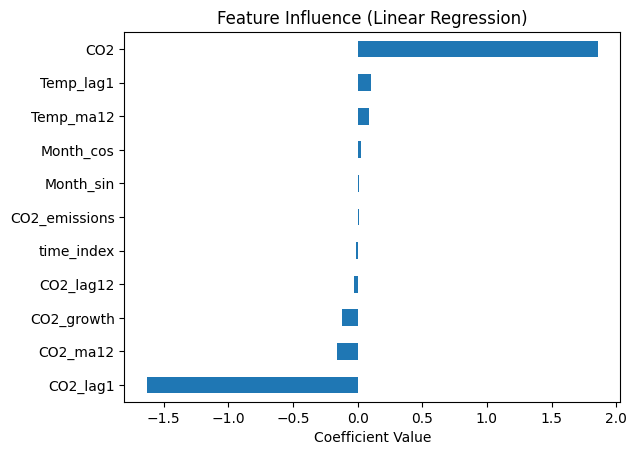

In [38]:
#use bar chart to show which features most influence model
importance = pd.Series(lr.coef_, index=X.columns)

plt.figure()
importance.sort_values().plot(kind="barh")
plt.title("Feature Influence (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.show()

# Visualization

Time series of Co2 vs Temp

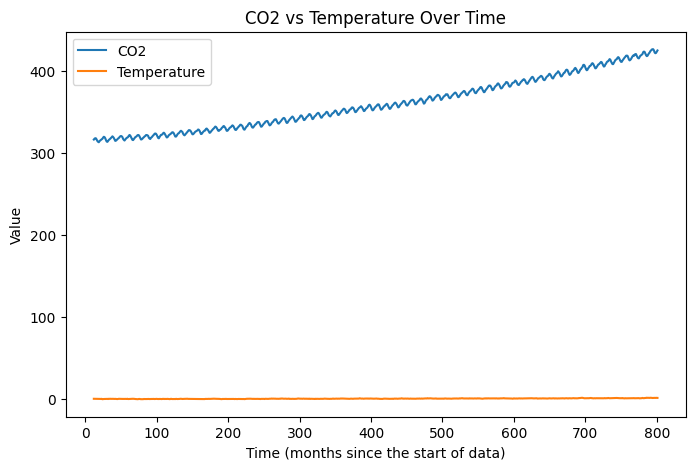

In [29]:
plt.figure(figsize=(8,5))

plt.plot(df["time_index"], df["CO2"], label="CO2")
plt.plot(df["time_index"], df["Temp"], label="Temperature")

plt.legend()
plt.title("CO2 vs Temperature Over Time")
plt.xlabel("Time (months since the start of data)")
plt.ylabel("Value")
plt.show()

Scatter plot for top features



In [24]:
# get top 3 features from model
top_features = importance.abs().sort_values(ascending=False).head(3).index

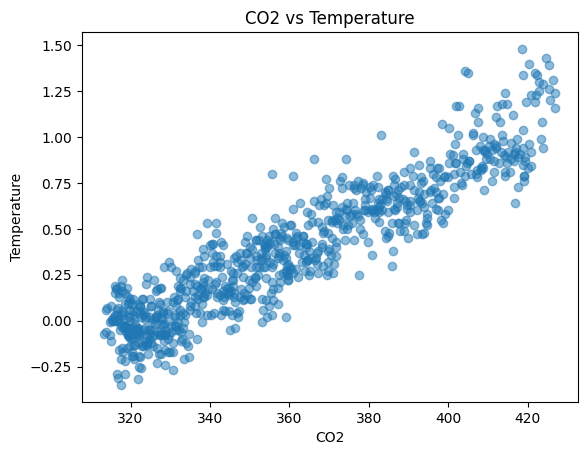

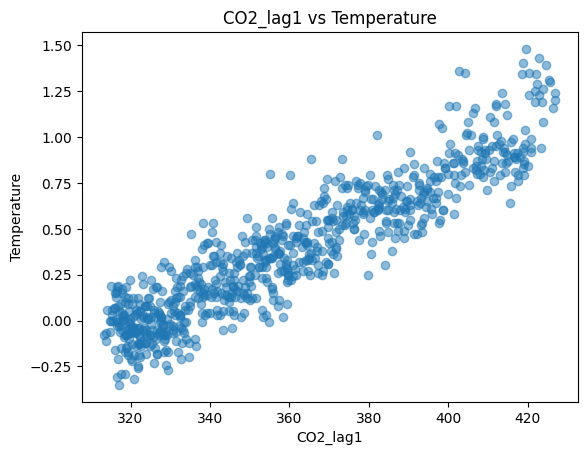

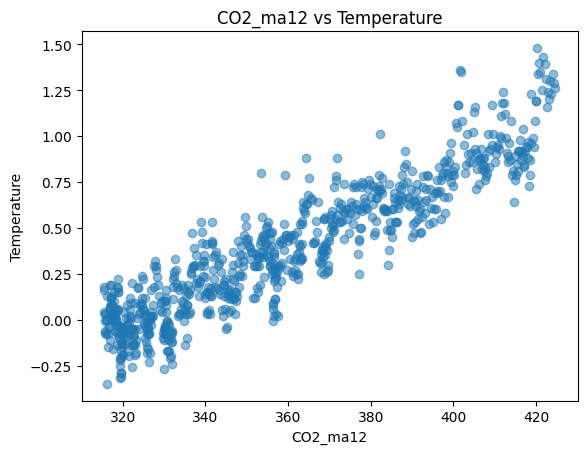

In [25]:
#use for loop to make scatter plots vs temp for all 3 top features
for feature in top_features:
    plt.figure()

    plt.scatter(df[feature], df["Temp"], alpha=0.5)

    plt.xlabel(feature)
    plt.ylabel("Temperature")
    plt.title(f"{feature} vs Temperature")

    plt.show()

In [39]:
#save final dataset as csv (for github)
df.to_csv("final_climate_dataset.csv", index=False)

# Discussion

The strongest contributors to temperature abnormality seem to be greenhouse gasses and the derivations of Co2 from the past (CO2_lag1 and CO2_ma12). This means that the concentrations of Co2 from the past and present day contribute to influencing temperature abnormalities. These results are consistent with established climate science. Scientists agree that concentrations of CO2 are the main cause of global warming today which coinsides with the results of the regression model.

The biggest challenge in this project was preprosessing and merging the data together. The NOAA and NASA GISS datasets were monthly datasets while OWID data was annually. The way NASA GISS was formatted created created problems as months were on the x-axis and year was on the y-axis. To fix this I had to "melt" the data so that each row in represented the month and year, which left me with over a thousand data points. However, when I had to merge the datasets together, I had to focus on Year, leading to a lot of data being lost. After filtering out the data points that did not have a value for C02 or Temperature, I was left with 816 data points in the dataset. After feature engineering, I was left with even less.

Although the linear regression model does identify the relationship between CO2 and temperature abnormalities, that does not prove that it is the sole cause of it. Other factors that were not included like solar irradiance and volcanic activity were not considered. Other ethical concerns arise when it comes to data reliability, as scientists might include bias in their data to further influence agendas.

Overall, the linear regression model shows a strong association between CO2 concentration and temperature anomalies.